In [2]:
%pip install meteostat
%pip install scipy
%pip intall matplotlib.pyplot




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: unknown command "intall" - maybe you meant "install"
Note: you may need to restart the kernel to use updated packages.


In [3]:
from datetime import date
import meteostat as ms
from meteostat import Point, daily
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt



In [4]:
##Loading data from meteostat from Orly weather station based on station ID
STATION_ID = '07149'
orly = ms.Station(id=STATION_ID)

# Use a short range that is definitely within the inventory
start = date(2000, 1, 1)
end   = date(2024, 12, 31)

ts = ms.daily(orly, start, end)
df = ts.fetch()

print(df.head())

            temp  tmin  tmax  rhum  prcp  snwd  wspd  wpgt    pres  tsun  cldc
time                                                                          
2000-01-01   7.9   6.3   9.4    98   0.2  <NA>  10.6  <NA>  1026.2  <NA>     8
2000-01-02   7.1   6.6   9.1    98   0.0  <NA>   8.9  <NA>  1029.5  <NA>  <NA>
2000-01-03   5.9   4.4   7.7    95   0.0  <NA>  16.4  <NA>  1027.0  <NA>     7
2000-01-04   7.9   6.1   9.4    94   1.6  <NA>  25.8  <NA>  1020.5  <NA>     7
2000-01-05   7.3   6.9   9.5    95   0.0  <NA>  12.9  <NA>    <NA>  <NA>  <NA>


### Check, clean and prepare df

In [5]:
print(df.dtypes)
print(df.isna().sum())
## we can see that there are missing values in avg temperature

temp    Float64
tmin    Float64
tmax    Float64
rhum      UInt8
prcp    Float64
snwd     UInt16
wspd    Float64
wpgt    Float64
pres    Float64
tsun     UInt16
cldc      UInt8
dtype: object
temp     365
tmin       0
tmax       0
rhum     397
prcp       0
snwd    9036
wspd     391
wpgt    6788
pres     664
tsun    8268
cldc    2521
dtype: int64


In [6]:
# Keep only the columns we need
df = df[['tmin', 'tmax']].copy()

# Ensure numeric types
df['tmin'] = pd.to_numeric(df['tmin'], errors='coerce')
df['tmax'] = pd.to_numeric(df['tmax'], errors='coerce')

# Sort & ensure datetime index
df = df.sort_index()
print(df.head())



            tmin  tmax
time                  
2000-01-01   6.3   9.4
2000-01-02   6.6   9.1
2000-01-03   4.4   7.7
2000-01-04   6.1   9.4
2000-01-05   6.9   9.5


In [7]:
## calculate average ourselves, to ensure no nulls based on the CME style 
df['tavg'] = (df['tmin'] + df['tmax']) / 2
print(df.head())

            tmin  tmax  tavg
time                        
2000-01-01   6.3   9.4  7.85
2000-01-02   6.6   9.1  7.85
2000-01-03   4.4   7.7  6.05
2000-01-04   6.1   9.4  7.75
2000-01-05   6.9   9.5   8.2


In [8]:
print(df[['tmin', 'tmax', 'tavg']].describe())
print(df.isna().sum())


           tmin       tmax      tavg
count    9132.0     9132.0    9132.0
mean   8.218408  16.653471  12.43594
std    5.871562   7.789155  6.602354
min       -13.3       -5.1      -8.1
25%         4.0       10.8      7.55
50%         8.4       16.6     12.35
75%        12.8       22.6      17.6
max        24.4       41.9     33.15
tmin    0
tmax    0
tavg    0
dtype: int64


### compute values needed for HBA

In [9]:
EURO_PER_POINT = 20  # €20 per index point (CME spec)

# 1. Compute HDD & CDD if not already present
if 'tavg' not in df.columns:
    df['tavg'] = (df['tmin'] + df['tmax']) / 2

df['hdd'] = (18 - df['tavg']).clip(lower=0)
df['cdd'] = (df['tavg'] - 18).clip(lower=0)
df['cat'] = df['tavg'].clip(lower=0)

# 2. Monthly indices
monthly_hdd = df['hdd'].resample('ME').sum()
monthly_cdd = df['cdd'].resample('ME').sum()
monthly_cat = df['cat'].resample('ME').sum()

# 3. Convert to € settlement per contract
monthly_hdd_eur = monthly_hdd * EURO_PER_POINT
monthly_cdd_eur = monthly_cdd * EURO_PER_POINT
monthly_cat_eur = monthly_cat * EURO_PER_POINT


# 4. Create panel DataFrame for timeseries purpose
monthly_panel = pd.DataFrame({
    'hdd_eur': monthly_hdd_eur,
    'cat_eur': monthly_cat_eur,
})

# Add explicit year and month identifiers
monthly_panel['year'] = monthly_panel.index.year
monthly_panel['month'] = monthly_panel.index.month

# Use (year, month) as index
monthly_panel = monthly_panel.set_index(['year', 'month']).sort_index()





In [10]:
#create a loop for all 12 months of the year to calculate burn stats
rows_hdd = []
rows_cdd = []
rows_cat = []

for month in range(1, 12 + 1):
    # --- HDD stats ---
    hdd_vals = monthly_hdd_eur[monthly_hdd_eur.index.month == month]
    
    if len(hdd_vals) > 0:
        rows_hdd.append({
            "month": month,
            "n_years": len(hdd_vals),
            "mean_burn": hdd_vals.mean(),          # expected payout (burn price)
            "std": hdd_vals.std(),                 # volatility
            "min": hdd_vals.min(),
            "p10": hdd_vals.quantile(0.10),
            "median": hdd_vals.median(),
            "p90": hdd_vals.quantile(0.90),
            "max": hdd_vals.max(),
        })
    else:
        rows_hdd.append({
            "month": month,
            "n_years": 0,
            "mean_burn": np.nan,
            "std": np.nan,
            "min": np.nan,
            "p10": np.nan,
            "median": np.nan,
            "p90": np.nan,
            "max": np.nan,
        })

    # --- CDD stats ---
    cdd_vals = monthly_cdd_eur[monthly_cdd_eur.index.month == month]
    
    if len(cdd_vals) > 0:
        rows_cdd.append({
            "month": month,
            "n_years": len(cdd_vals),
            "mean_burn": cdd_vals.mean(),
            "std": cdd_vals.std(),
            "min": cdd_vals.min(),
            "p10": cdd_vals.quantile(0.10),
            "median": cdd_vals.median(),
            "p90": cdd_vals.quantile(0.90),
            "max": cdd_vals.max(),
        })
    else:
        rows_cdd.append({
            "month": month,
            "n_years": 0,
            "mean_burn": np.nan,
            "std": np.nan,
            "min": np.nan,
            "p10": np.nan,
            "median": np.nan,
            "p90": np.nan,
            "max": np.nan,
        })
# --- CAT stats ---
    cat_vals = monthly_cat_eur[monthly_cat_eur.index.month == month]

    rows_cat.append({
        "month": month,
        "n_years": len(cat_vals),
        "mean_burn": cat_vals.mean(),
        "std": cat_vals.std(),
        "min": cat_vals.min(),
        "p10": cat_vals.quantile(0.10),
        "median": cat_vals.median(),
        "p90": cat_vals.quantile(0.90),
        "max": cat_vals.max(),
    })

# Turn into DataFrames
burn_hdd = pd.DataFrame(rows_hdd).set_index("month")
burn_cdd = pd.DataFrame(rows_cdd).set_index("month")
burn_cat = pd.DataFrame(rows_cat).set_index("month")

print("HDD burn stats (€/contract):")
print(burn_hdd)

print("\nCDD burn stats (€/contract):")
print(burn_cdd)

print("\nCAT burn stats (€/contract):")
print(burn_cat)



HDD burn stats (€/contract):
       n_years  mean_burn          std     min     p10  median     p90  \
month                                                                    
1           25    8225.64  1102.707799  6445.0  6983.6  8234.0  9742.4   
2           25    6927.56  1213.913989  5176.0  5507.2  6690.0  8410.0   
3           25    5927.84   848.282268  4688.0  4839.0  5919.0  6820.0   
4           25    3925.32   920.020730  1992.0  2508.2  4006.0  5048.6   
5           25    2107.72   676.314555   967.0  1391.6  1943.0  2996.4   
6           25     598.04   310.416854     7.0   209.4   626.0  1006.0   
7           25     205.60   210.591231     0.0     3.6   122.0   475.8   
8           25     211.36   177.453017     0.0    56.4   140.0   502.0   
9           25    1120.56   571.492496   237.0   458.4  1041.0  1890.8   
10          25    3028.12   948.912110  1387.0  1782.6  3231.0  4104.4   
11          25    5803.28   755.425792  4321.0  4859.2  5917.0  6756.6   
12       

### HDD vs 2027 prices

In [11]:
# ----------------------
# HDD: listed months & 2027 prices
# ----------------------
# https://www.cmegroup.com/markets/weather/hdd/paris-hdd-monthly.settlements.html

EURO_PER_POINT = 20.0  # contract multiplier

# Listed HDD months on CME (Oct–Apr)
listed_hdd_months = [10, 11, 12, 1, 2, 3, 4]

# Subset burn table to listed months
hdd_listed = burn_hdd.loc[listed_hdd_months].copy()
hdd_listed['month_name'] = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']

# HDD 2027 settlement prices (index points)
hdd_2027_prices = {
    10: 143.0,   # Oct 27
    11: 281.0,   # Nov 27
    12: 366.0,   # Dec 27
    1:  404.0,   # Jan 27
    2:  332.0,   # Feb 27
    3:  284.0,   # Mar 27
    4:  189.0,   # Apr 27
}

hdd_market_2027 = pd.DataFrame.from_dict(
    hdd_2027_prices, orient='index', columns=['settle_index_2027']
)
hdd_market_2027.index.name = 'month'

# Convert to € settlement
hdd_market_2027['market_eur_2027'] = (
    hdd_market_2027['settle_index_2027'] * EURO_PER_POINT
)

# Join with burn
hdd_comp_2027 = hdd_listed.join(hdd_market_2027)

# ----------------------
# Jewson-style uncertainty on expected payoff
# ----------------------
# burn_hdd['std'] is the std of the monthly payoff in €,
# so SE of the mean payoff is std / sqrt(N_y)
hdd_comp_2027['se_mean_burn'] = (
    hdd_comp_2027['std'] / np.sqrt(hdd_comp_2027['n_years'])
)

# 95% confidence interval for expected payoff μ_p
z_95 = 1.96
hdd_comp_2027['ci_mean_lower_95'] = (
    hdd_comp_2027['mean_burn'] - z_95 * hdd_comp_2027['se_mean_burn']
)
hdd_comp_2027['ci_mean_upper_95'] = (
    hdd_comp_2027['mean_burn'] + z_95 * hdd_comp_2027['se_mean_burn']
)

# ----------------------
# Jewson-style uncertainty on the 90th percentile (tail)
# ----------------------
# Var(q_p) ≈ (σ^2 / (2 N_y)) * (2 + [Φ^{-1}(1-p)]^2)
# Here σ is std of payoff in €, so the variance is in €^2.
p = 0.90
z_p = norm.ppf(1 - p)  # Φ^{-1}(1-p)

hdd_comp_2027['var_q90'] = (
    (hdd_comp_2027['std'] ** 2) / (2 * hdd_comp_2027['n_years'])
    * (2 + z_p**2)
)
hdd_comp_2027['se_q90'] = np.sqrt(hdd_comp_2027['var_q90'])

# ----------------------
# Market vs burn
# ----------------------
hdd_comp_2027['market_minus_burn'] = (
    hdd_comp_2027['market_eur_2027'] - hdd_comp_2027['mean_burn']
)
hdd_comp_2027['market_over_burn'] = (
    hdd_comp_2027['market_eur_2027'] / hdd_comp_2027['mean_burn']
)

print("HDD 2027 vs burn (€/contract) with uncertainty:")
print(
    hdd_comp_2027[
        [
            'month_name',
            'n_years',
            'mean_burn',
            'se_mean_burn',
            'ci_mean_lower_95',
            'ci_mean_upper_95',
            'market_eur_2027',
            'market_minus_burn',
            'market_over_burn',
            'p10',
            'p90',
            'se_q90',
            'max',
        ]
    ]
)


HDD 2027 vs burn (€/contract) with uncertainty:
      month_name  n_years  mean_burn  se_mean_burn  ci_mean_lower_95  \
month                                                                  
10           Oct       25    3028.12    189.782422       2656.146453   
11           Nov       25    5803.28    151.085158       5507.153090   
12           Dec       25    7779.32    229.243769       7330.002212   
1            Jan       25    8225.64    220.541560       7793.378543   
2            Feb       25    6927.56    242.782798       6451.705716   
3            Mar       25    5927.84    169.656454       5595.313351   
4            Apr       25    3925.32    184.004146       3564.671874   

       ci_mean_upper_95  market_eur_2027  market_minus_burn  market_over_burn  \
month                                                                           
10          3400.093547           2860.0            -168.12          0.944480   
11          6099.406910           5620.0            -183.28 

### CAT vs 2027 prices 

In [12]:

# ----------------------
# CAT: listed months & 2027 prices
# ----------------------
# https://www.cmegroup.com/markets/weather/cat/paris-cat-monthly.settlements.html

EURO_PER_POINT = 20.0  # already used earlier

# Listed CAT months on CME (Paris, Apr–Oct)
listed_cat_months = [4, 5, 6, 7, 8, 9, 10]

# IMPORTANT: use burn_cat, not burn_cdd
cat_listed = burn_cat.loc[listed_cat_months].copy()
cat_listed['month_name'] = ['April', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'October']

# CAT 2027 settlement prices (index points)
cat_2027_prices = {
    4: 352.0,   # Apr 27
    5: 468.0,   # May 27
    6: 576.0,   # Jun 27
    7: 653.0,   # Jul 27
    8: 642.0,   # Aug 27
    9: 522.0,   # Sep 27
    10: 418.0,  # Oct 27
}

cat_market_2027 = pd.DataFrame.from_dict(
    cat_2027_prices, orient='index', columns=['settle_index_2027']
)
cat_market_2027.index.name = 'month'

# Convert to € settlement
cat_market_2027['market_eur_2027'] = (
    cat_market_2027['settle_index_2027'] * EURO_PER_POINT
)

# Join with burn table
cat_comp_2027 = cat_listed.join(cat_market_2027)

# ----------------------
# Jewson-style uncertainty on expected payoff
# ----------------------
# std in burn_cat is already the std of the payoff in €,
# so SE of the mean payoff is std / sqrt(N_y)
cat_comp_2027['se_mean_burn'] = (
    cat_comp_2027['std'] / np.sqrt(cat_comp_2027['n_years'])
)

# 95% confidence interval for expected payoff μ_p
z_95 = 1.96
cat_comp_2027['ci_mean_lower_95'] = (
    cat_comp_2027['mean_burn'] - z_95 * cat_comp_2027['se_mean_burn']
)
cat_comp_2027['ci_mean_upper_95'] = (
    cat_comp_2027['mean_burn'] + z_95 * cat_comp_2027['se_mean_burn']
)

# ----------------------
# Jewson-style uncertainty on the 90th percentile (tail)
# ----------------------
# Jewson approx (adapted to payoff units):
# Var(q_p) ≈ (σ^2 / (2 N_y)) * (2 + [Φ^{-1}(1-p)]^2)
# Here σ is std of payoff in €, so the formula is directly in €^2.
p = 0.90
z_p = norm.ppf(1 - p)  # Φ^{-1}(1-p)

cat_comp_2027['var_q90'] = (
    (cat_comp_2027['std'] ** 2) / (2 * cat_comp_2027['n_years'])
    * (2 + z_p**2)
)
cat_comp_2027['se_q90'] = np.sqrt(cat_comp_2027['var_q90'])

# ----------------------
# Market vs burn
# ----------------------
cat_comp_2027['market_minus_burn'] = (
    cat_comp_2027['market_eur_2027'] - cat_comp_2027['mean_burn']
)
cat_comp_2027['market_over_burn'] = (
    cat_comp_2027['market_eur_2027'] / cat_comp_2027['mean_burn']
)

print("CAT 2027 vs burn (€/contract) with uncertainty:")
print(
    cat_comp_2027[
        [
            'month_name',
            'n_years',
            'mean_burn',
            'se_mean_burn',
            'ci_mean_lower_95',
            'ci_mean_upper_95',
            'market_eur_2027',
            'market_minus_burn',
            'market_over_burn',
            'p10',
            'p90',
            'se_q90',
            'max',
        ]
    ]
)


CAT 2027 vs burn (€/contract) with uncertainty:
      month_name  n_years  mean_burn  se_mean_burn  ci_mean_lower_95  \
month                                                                  
4          April       25    6898.44    190.990664       6524.098299   
5            May       25    9265.40    159.832579       8952.128145   
6            Jun       25   11228.80    150.512281      10933.795930   
7            Jul       25   12742.80    202.475628      12345.947769   
8            Aug       25   12534.12    196.468049      12149.042623   
9            Sep       25   10197.16    199.051431       9807.019195   
10       October       25    8188.00    196.913153       7802.050219   

       ci_mean_upper_95  market_eur_2027  market_minus_burn  market_over_burn  \
month                                                                           
4           7272.781701           7040.0             141.56          1.020521   
5           9578.671855           9360.0              94.60 

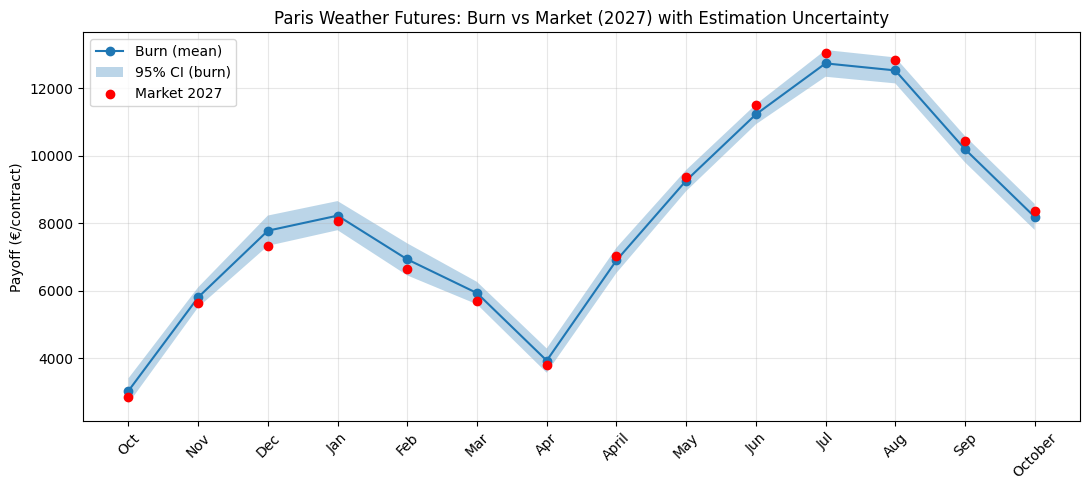

In [13]:
# Combine HDD and CAT into a single timeline
plot_df = pd.concat([
    hdd_comp_2027[['month_name', 'mean_burn',
                   'ci_mean_lower_95', 'ci_mean_upper_95',
                   'market_eur_2027']],
    cat_comp_2027[['month_name', 'mean_burn',
                   'ci_mean_lower_95', 'ci_mean_upper_95',
                   'market_eur_2027']]
])

# Define chronological order
order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr',
         'April', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'October']

plot_df['month_name'] = pd.Categorical(plot_df['month_name'], categories=order, ordered=True)
plot_df = plot_df.sort_values('month_name')

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(11, 5))

# Burn mean
ax.plot(x, plot_df['mean_burn'], label='Burn (mean)', marker='o')

# Confidence interval
ax.fill_between(
    x,
    plot_df['ci_mean_lower_95'],
    plot_df['ci_mean_upper_95'],
    alpha=0.3,
    label='95% CI (burn)'
)

# Market price
ax.scatter(
    x,
    plot_df['market_eur_2027'],
    color='red',
    zorder=5,
    label='Market 2027'
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['month_name'], rotation=45)
ax.set_ylabel('Payoff (€/contract)')
ax.set_title('Paris Weather Futures: Burn vs Market (2027) with Estimation Uncertainty')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Backtesting out of sample

In [14]:
def hba_backtest(
    monthly_panel: pd.DataFrame,
    product_col: str,
    listed_months: list,
    start_year: int,
    end_year: int,
    min_history_years: int = 10,
) -> pd.DataFrame:
    """
    Out-of-sample HBA backtest for a given product (hdd_eur or cat_eur).

    For each (year, month), predicts the payoff as the mean of past years'
    payoffs for the same month (expanding window), then compares to realized.
    """
    rows = []

    # full available years in data
    all_years = sorted({y for (y, m) in monthly_panel.index})

    for year in range(start_year, end_year + 1):
        if year not in all_years:
            continue

        for month in listed_months:
            if (year, month) not in monthly_panel.index:
                continue

            # Historical sample: all previous years for the same month
            hist_idx = [(y, month) for y in all_years if y < year and (y, month) in monthly_panel.index]
            if len(hist_idx) < min_history_years:
                # Not enough history yet – skip or mark as NaN
                continue

            hist_vals = monthly_panel.loc[hist_idx, product_col].dropna()

            if hist_vals.empty:
                continue

            hba_pred = hist_vals.mean()
            hba_std = hist_vals.std()

            realized = monthly_panel.loc[(year, month), product_col]

            rows.append({
                'year': year,
                'month': month,
                'product': product_col,
                'hba_pred': hba_pred,
                'hba_std_hist': hba_std,
                'realized': realized,
                'error': realized - hba_pred,
                'abs_error': abs(realized - hba_pred),
                'sq_error': (realized - hba_pred) ** 2,
                'n_hist_years': len(hist_vals),
            })

    return pd.DataFrame(rows).set_index(['year', 'month']).sort_index()


In [15]:
# HDD: listed months Oct–Apr
listed_hdd_months = [10, 11, 12, 1, 2, 3, 4]

# CAT: listed months Apr–Oct
listed_cat_months = [4, 5, 6, 7, 8, 9, 10]

# Backtest period
start_year = 2005  # at least 10 years of history from 1995
end_year = 2025    # last full year in temperature  dataset

hba_hdd_bt = hba_backtest(
    monthly_panel,
    product_col='hdd_eur',
    listed_months=listed_hdd_months,
    start_year=start_year,
    end_year=end_year,
    min_history_years=10,
)

hba_cat_bt = hba_backtest(
    monthly_panel,
    product_col='cat_eur',
    listed_months=listed_cat_months,
    start_year=start_year,
    end_year=end_year,
    min_history_years=10,
)

hba_hdd_bt.head(), hba_cat_bt.head()


(            product  hba_pred  hba_std_hist  realized   error  abs_error  \
 year month                                                                 
 2010 1      hdd_eur    8277.3   1123.107994   10668.0  2390.7     2390.7   
      2      hdd_eur    7025.3   1025.810904    7774.0   748.7      748.7   
      3      hdd_eur    6143.0    729.452154    6442.0   299.0      299.0   
      4      hdd_eur    3972.0    871.846954    4029.0    57.0       57.0   
      10     hdd_eur    3216.3   1171.952886    3967.0   750.7      750.7   
 
               sq_error  n_hist_years  
 year month                            
 2010 1      5715446.49            10  
      2       560551.69            10  
      3        89401.00            10  
      4         3249.00            10  
      10      563550.49            10  ,
             product  hba_pred  hba_std_hist  realized   error  abs_error  \
 year month                                                                 
 2010 4      cat_eur    

### HBA performance

In [16]:
# Combine HDD and CAT HBA backtests into a single panel
hba_bt_all = pd.concat([hba_hdd_bt, hba_cat_bt])
hba_bt_all = hba_bt_all.sort_index()

hba_mae = hba_bt_all['abs_error'].mean()
hba_rmse = np.sqrt(hba_bt_all['sq_error'].mean())

print(f"HBA MAE:  {hba_mae:.1f} €")
print(f"HBA RMSE: {hba_rmse:.1f} €")


HBA MAE:  815.2 €
HBA RMSE: 1002.6 €


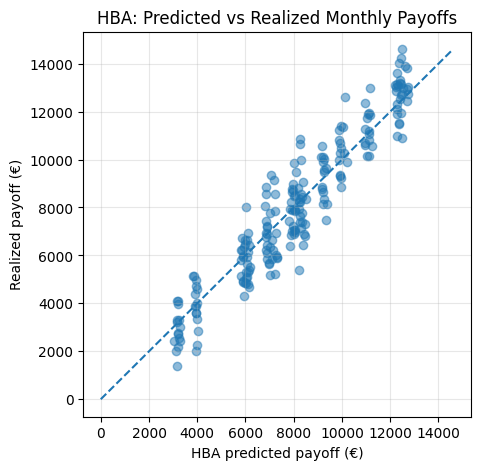

In [17]:
#Plotting out of sample results
plt.figure(figsize=(5,5))
plt.scatter(hba_bt_all['hba_pred'], hba_bt_all['realized'], alpha=0.5)
plt.plot([0, hba_bt_all['realized'].max()],
         [0, hba_bt_all['realized'].max()],
         linestyle='--')
plt.xlabel('HBA predicted payoff (€)')
plt.ylabel('Realized payoff (€)')
plt.title('HBA: Predicted vs Realized Monthly Payoffs')
plt.grid(alpha=0.3)
plt.show()


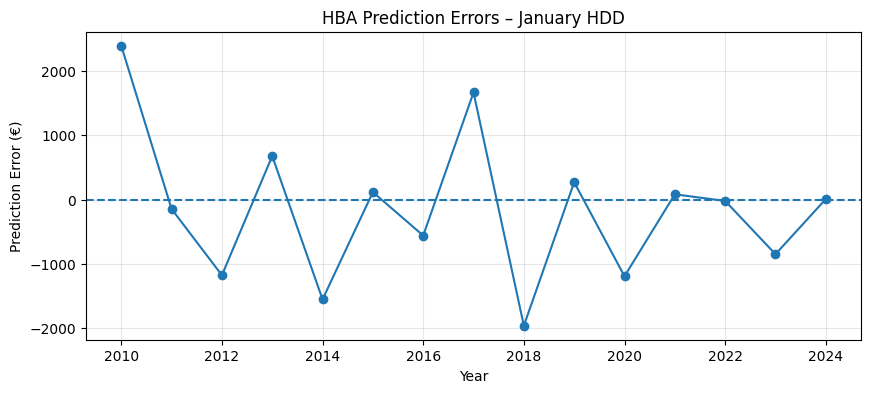

In [18]:
bt_df = hba_bt_all.reset_index() 
jan_hdd = bt_df[(bt_df['month'] == 1) & (bt_df['product'] == 'hdd_eur')]

plt.figure(figsize=(10, 4))
plt.plot(jan_hdd['year'], jan_hdd['error'], marker='o')
plt.axhline(0, linestyle='--')
plt.ylabel('Prediction Error (€)')
plt.xlabel('Year')
plt.title('HBA Prediction Errors – January HDD')
plt.grid(alpha=0.3)
plt.show()
